In [ ]:
# Data Visualization

## Objective

# Create visual representations of business insights 
# and key performance indicators for stakeholder reporting.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [9]:
print(os.getcwd())

/Users/macos/DataScienceProjects/AmazonSalesAnalyticsProject/notebooks


In [13]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nParent Folder Contents:")
print(os.listdir(".."))

print("\nCurrent Folder Contents:")
print(os.listdir("."))

Current Working Directory:
/Users/macos/DataScienceProjects/AmazonSalesAnalyticsProject/notebooks

Parent Folder Contents:
['.DS_Store', 'requirements.txt', 'images', 'README.md', 'venv', 'data', 'notebooks', 'reports']

Current Folder Contents:
['05_Visualizations.ipynb', '01_Data_Understanding.ipynb', '04_Customer_Value_Analysis.ipynb', '02_Data_Cleaning.ipynb', '03_Revenue_Analytics.ipynb']


In [14]:
import os

for root, dirs, files in os.walk("/Users/macos/DataScienceProjects/AmazonSalesAnalyticsProject"):
    if "amazon_cleaned.csv" in files:
        print("FOUND:", os.path.join(root, "amazon_cleaned.csv"))

FOUND: /Users/macos/DataScienceProjects/AmazonSalesAnalyticsProject/data/amazon_cleaned.csv


In [15]:
import pandas as pd

df = pd.read_csv("/Users/macos/DataScienceProjects/AmazonSalesAnalyticsProject/data/amazon_cleaned.csv")

print(df.shape)

(100000, 24)


In [16]:
category_revenue = (
    df.groupby("Category")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

brand_revenue = (
    df.groupby("Brand")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

payment_revenue = (
    df.groupby("PaymentMethod")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

df["OrderDate"] = pd.to_datetime(df["OrderDate"])

monthly_revenue = (
    df.groupby(df["OrderDate"].dt.to_period("M"))["TotalAmount"]
      .sum()
      .reset_index()
)

monthly_revenue["Date"] = monthly_revenue["OrderDate"].astype(str)

customer_revenue = (
    df.groupby("CustomerID")["TotalAmount"]
      .sum()
      .reset_index()
)

customer_revenue["Segment"] = pd.qcut(
    customer_revenue["TotalAmount"],
    q=4,
    labels=["Bronze", "Silver", "Gold", "Platinum"]
)

segment_revenue = (
    customer_revenue.groupby("Segment")["TotalAmount"]
      .sum()
)

In [17]:
import os

os.makedirs("images", exist_ok=True)

In [18]:
print(category_revenue.head())
print(brand_revenue.head())
print(payment_revenue.head())
print(segment_revenue)

Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Name: TotalAmount, dtype: float64
Brand
CoreTech      9343720.59
KiddoFun      9324749.55
ReadMore      9278406.63
UrbanStyle    9249027.45
Zenith        9239960.39
Name: TotalAmount, dtype: float64
PaymentMethod
Credit Card    32122158.69
Debit Card     18538678.53
UPI            13896028.55
Amazon Pay     13697498.42
Net Banking     9055674.57
Name: TotalAmount, dtype: float64
Segment
Bronze       4941079.94
Silver      14362973.09
Gold        25476404.70
Platinum    47045190.19
Name: TotalAmount, dtype: float64


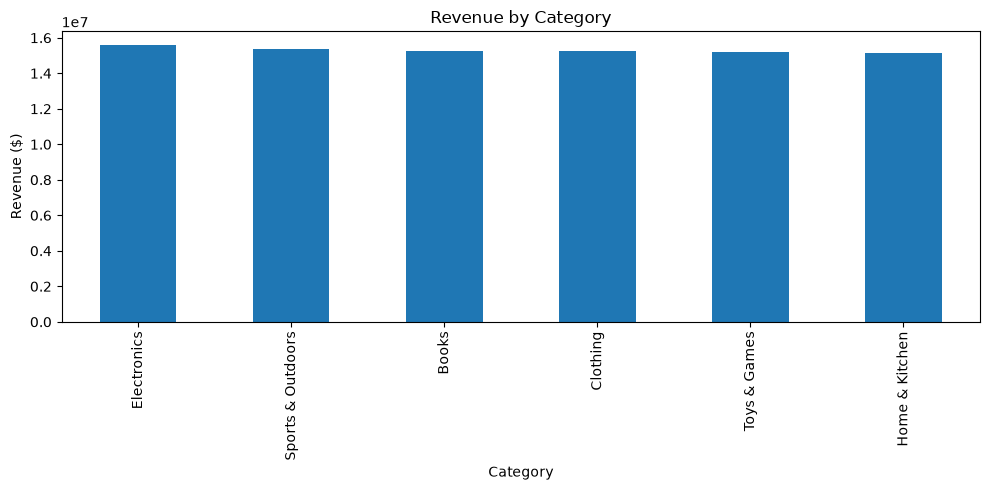

In [19]:
plt.figure(figsize=(10,5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue ($)")

plt.tight_layout()

plt.savefig("images/revenue_by_category.png")

plt.show()

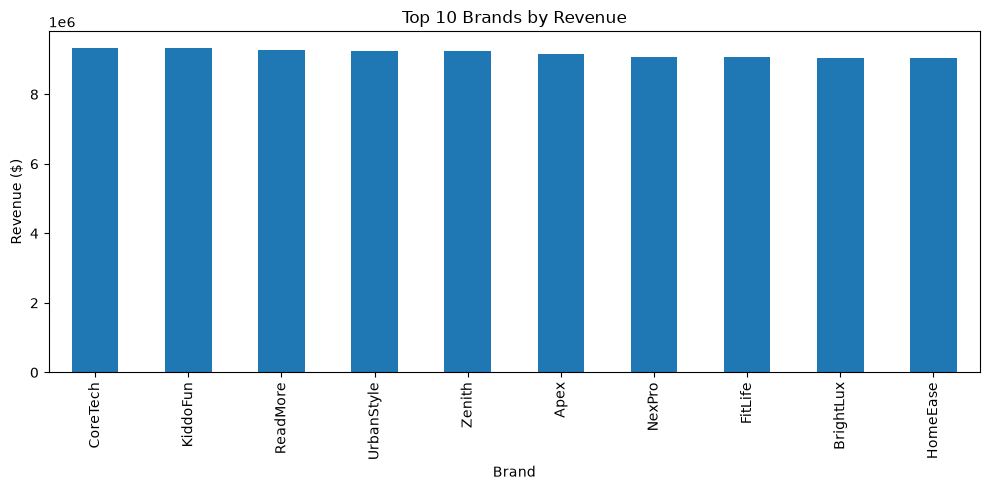

In [20]:
plt.figure(figsize=(10,5))

brand_revenue.head(10).plot(kind="bar")

plt.title("Top 10 Brands by Revenue")
plt.xlabel("Brand")
plt.ylabel("Revenue ($)")

plt.tight_layout()

plt.savefig("images/top_brands_revenue.png")

plt.show()

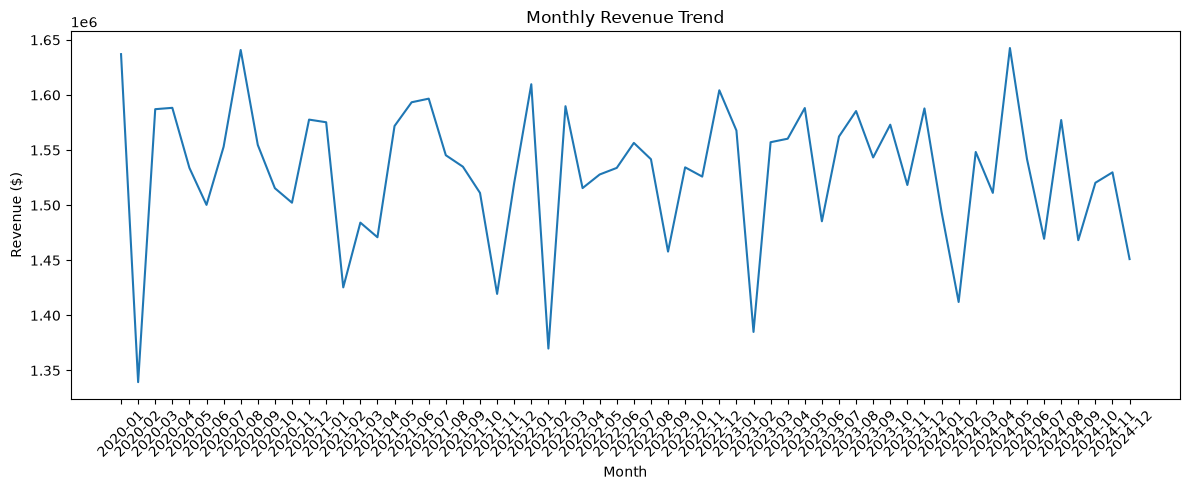

In [21]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue["Date"],
    monthly_revenue["TotalAmount"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("images/monthly_revenue_trend.png")

plt.show()

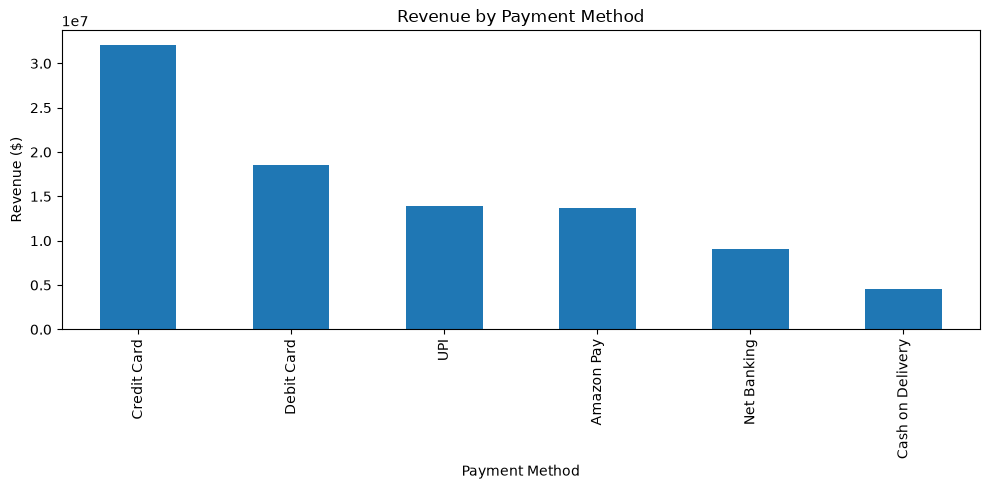

In [22]:
plt.figure(figsize=(10,5))

payment_revenue.plot(kind="bar")

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue ($)")

plt.tight_layout()

plt.savefig("images/payment_method_revenue.png")

plt.show()

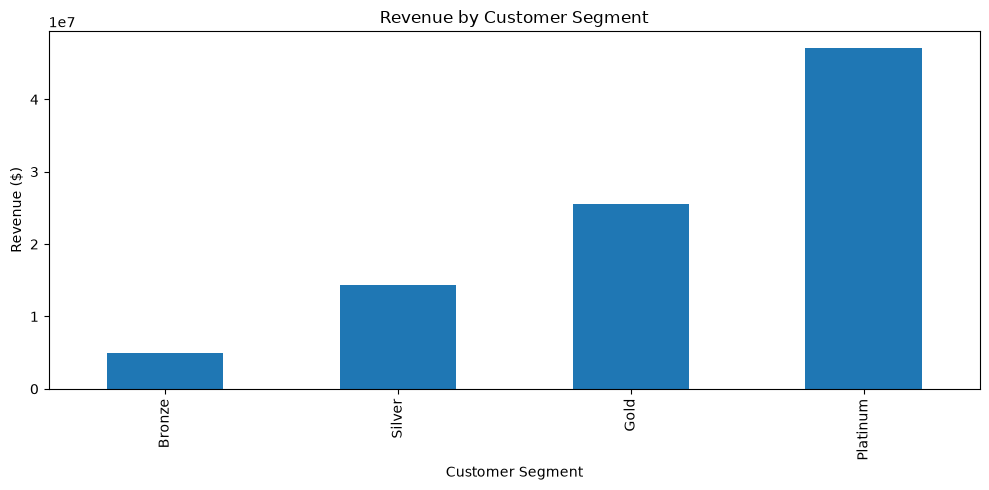

In [23]:
plt.figure(figsize=(10,5))

segment_revenue.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue ($)")

plt.tight_layout()

plt.savefig("images/customer_segment_revenue.png")

plt.show()

In [24]:
import os

print(os.listdir("images"))

['top_brands_revenue.png', 'monthly_revenue_trend.png', 'revenue_by_category.png', 'payment_method_revenue.png', 'customer_segment_revenue.png']


In [ ]:
# Conclusion

# The analysis revealed that revenue is concentrated among a small group of high-performing categories, brands, and locations.
# These findings can help prioritize marketing investment and inventory planning.